In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/social-media-user-activity-dataset/instagram_usage_lifestyle.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("/kaggle/input/social-media-user-activity-dataset/instagram_usage_lifestyle.csv")
df.head()


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


**ُEDA**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

In [5]:
df.isnull().sum()

user_id                           0
app_name                          0
age                               0
gender                            0
country                           0
urban_rural                       0
income_level                      0
employment_status                 0
education_level                   0
relationship_status               0
has_children                      0
exercise_hours_per_week           0
sleep_hours_per_night             0
diet_quality                      0
smoking                           0
alcohol_frequency                 0
perceived_stress_score            0
self_reported_happiness           0
body_mass_index                   0
blood_pressure_systolic           0
blood_pressure_diastolic          0
daily_steps_count                 0
weekly_work_hours                 0
hobbies_count                     0
social_events_per_month           0
books_read_per_year               0
volunteer_hours_per_month         0
travel_frequency_per_year   

In [6]:
df.nunique()

user_id                           1547896
app_name                                1
age                                    53
gender                                  4
country                                10
urban_rural                             3
income_level                            5
employment_status                       6
education_level                         6
relationship_status                     5
has_children                            2
exercise_hours_per_week               241
sleep_hours_per_night                  71
diet_quality                            5
smoking                                 3
alcohol_frequency                       5
perceived_stress_score                 41
self_reported_happiness                10
body_mass_index                       286
blood_pressure_systolic                70
blood_pressure_diastolic               40
daily_steps_count                     773
weekly_work_hours                     800
hobbies_count                     

In [7]:
# Loop through categorical variables and show frequency counts
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-" * 40)


Value counts for app_name:
app_name
Instagram    1547896
Name: count, dtype: int64
----------------------------------------
Value counts for gender:
gender
Male                 743169
Female               742847
Non-binary            46196
Prefer not to say     15684
Name: count, dtype: int64
----------------------------------------
Value counts for country:
country
United States     386829
India             278342
Brazil            186258
Other             154572
United Kingdom    123411
Canada            108584
Australia          92522
South Korea        78050
Germany            77329
Japan              61999
Name: count, dtype: int64
----------------------------------------
Value counts for urban_rural:
urban_rural
Urban       850754
Suburban    464605
Rural       232537
Name: count, dtype: int64
----------------------------------------
Value counts for income_level:
income_level
Middle          465037
Lower-middle    386815
Low             309736
Upper-middle    231747
High        

In [8]:
# Disable scientific notation for pandas
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Show descriptive statistics
print(df.describe())


         user_id        age  exercise_hours_per_week  sleep_hours_per_night  \
count 1547896.00 1547896.00               1547896.00             1547896.00   
mean   773948.50      38.99                     7.14                   7.00   
std    446839.23      15.29                     3.99                   1.10   
min         1.00      13.00                     0.00                   3.00   
25%    386974.75      26.00                     4.00                   6.30   
50%    773948.50      39.00                     6.60                   7.00   
75%   1160922.25      52.00                     9.70                   7.70   
max   1547896.00      65.00                    24.10                  10.00   

       perceived_stress_score  self_reported_happiness  body_mass_index  \
count              1547896.00               1547896.00       1547896.00   
mean                    19.99                     5.50            25.00   
std                     11.83                     2.87         

**Data visualization**

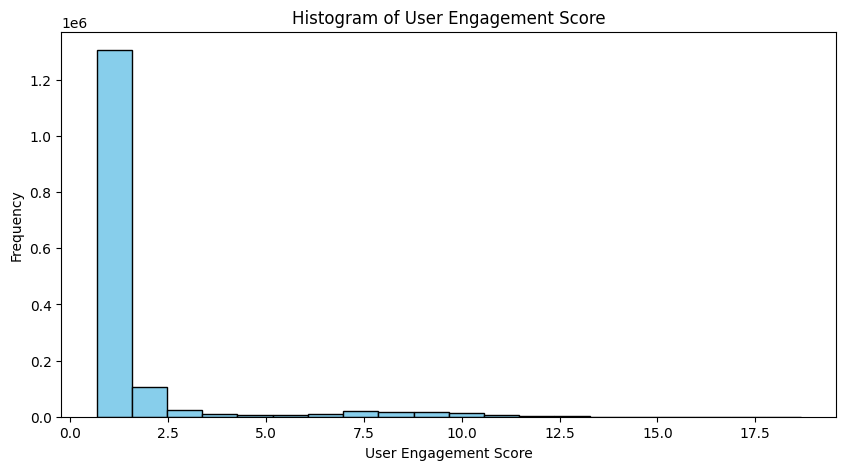

In [9]:
# Histogram of user_engagement_score
plt.figure(figsize=(10, 5))
plt.hist(df['user_engagement_score'], bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of User Engagement Score")
plt.xlabel("User Engagement Score")
plt.ylabel("Frequency")
plt.show()


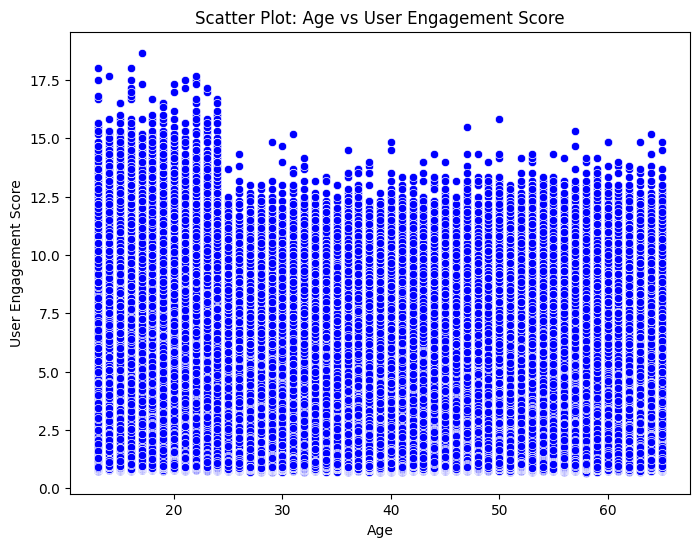

In [10]:
# Scatter plot of age vs user_engagement_score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='user_engagement_score', data=df, color='blue')
plt.title("Scatter Plot: Age vs User Engagement Score")
plt.xlabel("Age")
plt.ylabel("User Engagement Score")
plt.show()


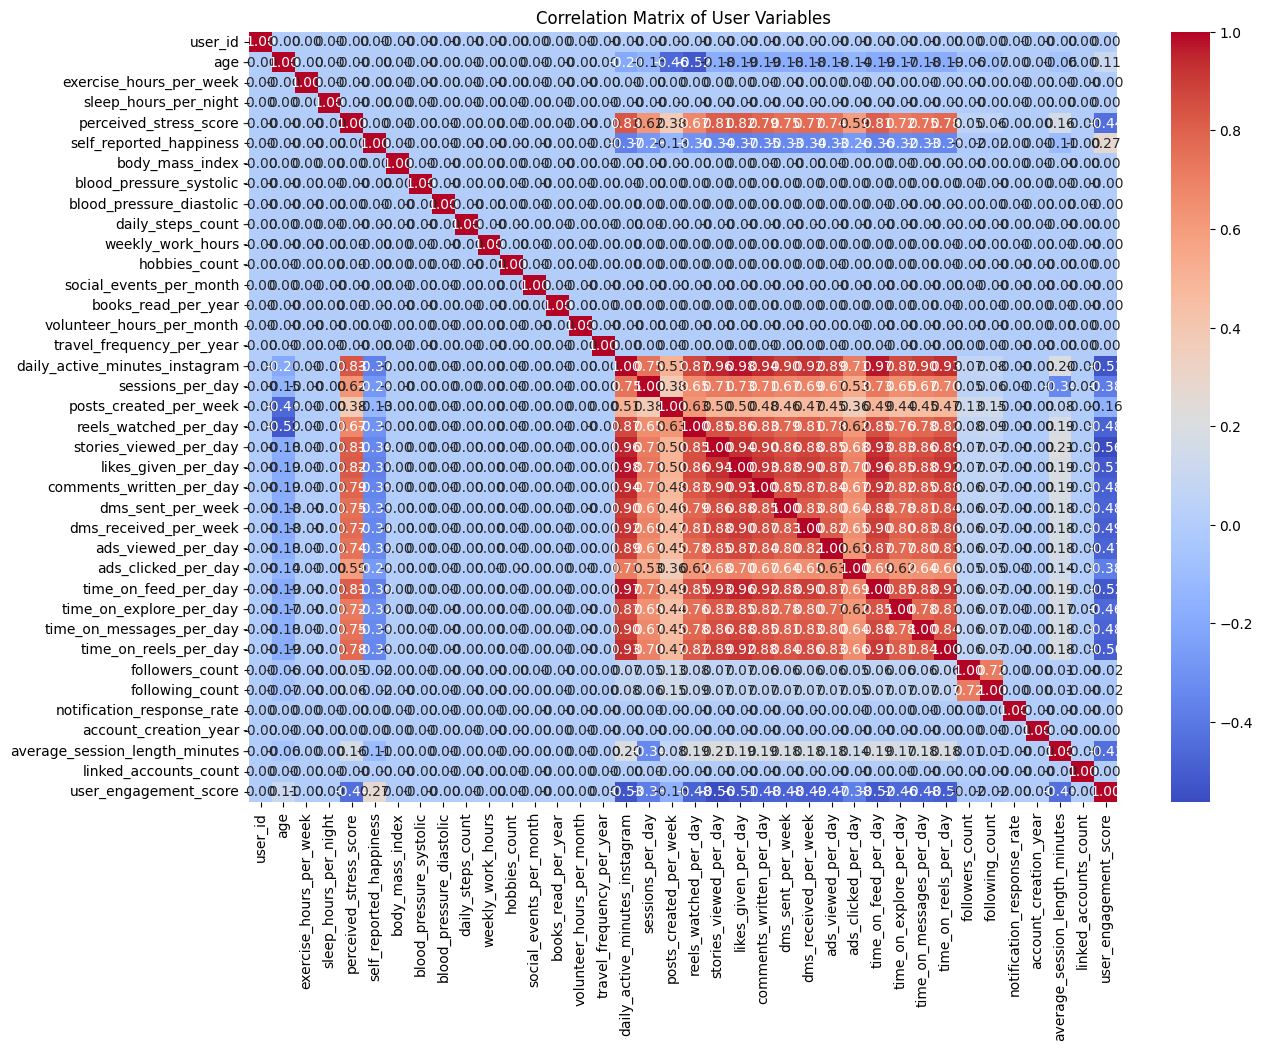

In [11]:
# Select numeric columns only (correlation works on numbers)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Matrix of User Variables")
plt.show()


**I invite you to join the HAGO community for data scientists, where you can learn, compete, predict future events, and take IQ tests.**

**https://www.skool.com/hago-8156/about**